## Task 1: Data Exploration, Pre-Processing and Augmentation

In this task, you will create a pipeline to load and transform your training, validation, and test data. Create a Jupyter notebook named `preprocessing.ipynb`, implementing the requirements below.

### 1. Loading the data
- Create the dataset based on the `KneeOA` folder.
- Load the images as tensors. Note that the images are provided as `.png` files, which are typically loaded with three channels (RGB). However, since these are grayscale X-ray images, the three channels are identical. Hence, the inputs can be simplified to a single channel. Note that some pretrained models used in Task 3 do require three input channels, so you may have to adapt your dataset later on.

### 2. Data Exploration
- Print the size of the training, validation, and test sets.
- Show the distribution of the classes.
- Plot a few samples from each class with their corresponding labels.
- Explore and display statistics on the pixel intensities (e.g., pixel average, global average, pixel standard deviation, global standard deviation, ...).

### 3. Pre-processing
- Check the original image size. Downsample the images by resizing them to 128 × 128 pixels. This decreases the image resolution and loses some information. Nevertheless, it lowers the computational requirements in future steps.
- Implement a normalization strategy using fixed values, sample statistics, or the statistics of the training dataset, and test it on a sample from the validation dataset.

### 4. Augmentation
- Implement at least two different relevant types of data augmentation.
- Visualize the transformations on a sample from the training dataset, both individually and combined.

### 5. Pipeline
- Implement the full pipeline for preprocessing and data augmentation for the next tasks.
- Reflect on whether data augmentation should be applied to the validation and test sets.

---

In your report, provide a detailed discussion of the dataset and the preprocessing steps you implemented, addressing the following aspects:

- **Dataset:** Clearly discuss the dataset used and its statistics.
- **Classification challenges:** Discuss the intrinsic difficulties of the dataset and its distribution for the classification task. This includes, for example, the observed image variability and class distribution.
- **Image handling:** Discuss how you preprocessed your images. This includes the chosen normalization and data augmentation. Clearly motivate your choices.

----
----

## Setup

In [78]:
# install dependencies
# You can run this directly here or in your terminal (without the !)
#!pip install -r ../0_generalcode/requirements.txt

In [79]:
# import external modules
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

In [80]:
# We need to work with torch; so try to set the GPU backend for that.
import sys

sys.path.insert(0, "../0_generalcode")
from gpu_helper import settest_torch_gpu

settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow


## Visual inspections:
- trainset: 500 (0) / 250(1) -> opletten voor false negatives (overfitting on class 0) ?

Intuitief te volgen stappen
- weinig samples met bouten, maar lijkt gelijk verdeeld over 0/1 -> later eventueel te bekijken indien die consequent fout zijn (verwijderen ?)
- vertical flip; All beelden zijn rechts of links, er is geen invloed op de classificatie (0/1) ; dit zou niet kunnen voor bvb torso-xray waarbij we links of rechts iets moeten vaststellen 
- small rotations ?
- resize to 128x128 (op alle sets (train/validate/test) 
- light intensity augmentation (er zijn beelden van verschillende lichtintensiteit) !
- noise/blur ?
- tensor / normalization



In [81]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def plot_images(image_paths, titles=None) -> None:
    n = len(image_paths)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    # If only one image, axes is not a list → fix it
    if n == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        img = mpimg.imread(image_paths[i])
        ax.imshow(img, cmap="gray")
        ax.axis("off")

        if titles:
            ax.set_title(titles[i])

    plt.tight_layout()
    plt.show()

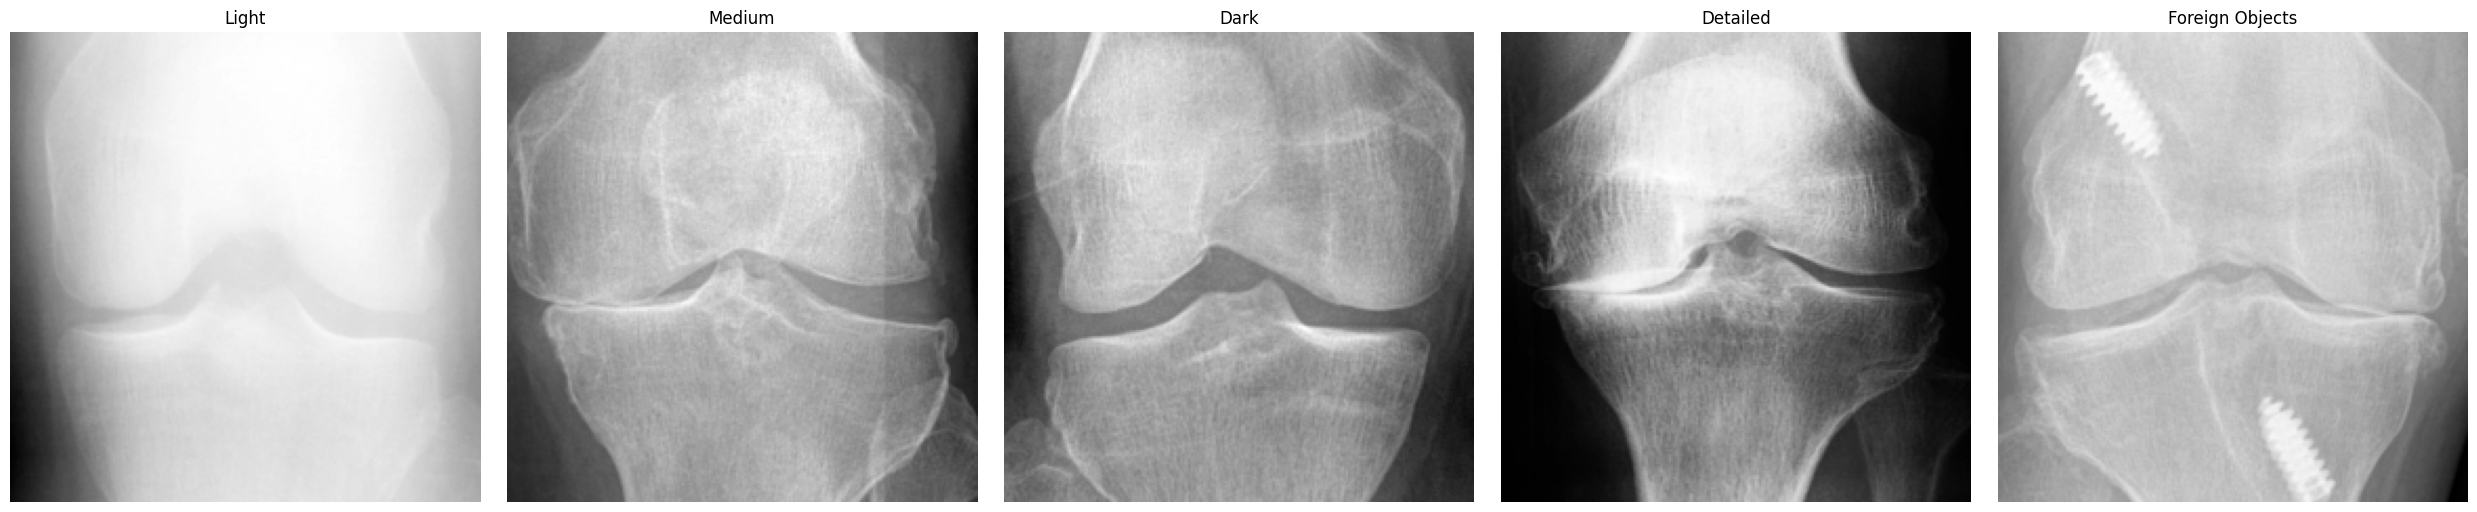

In [82]:
images = [
    "../../data/1_source/train/0/9003126L.png",
    "../../data/1_source/train/1/9075815L.png",
    "../../data/1_source/train/0/9102958R.png",
    "../../data/1_source/train/1/9053047L.png",
    "../../data/1_source/train/1/9529676R.png",
]
titles = ["Light", "Medium", "Dark", "Detailed", "Foreign Objects"]

plot_images(images, titles)

A visual inspection in the file explorer shows that there are some variations in the input images. 

We see variations in lighting (light,medium, dark); although the displaying in notebook shows less difference between medium and dark.
There are also some images which appear to have more details than others.
=> this indicates the need for augmentation on these aspects.

A minority of the samples show foreign objects (screws/plates/overlays). detailed model inspection needed to see if these objects influence the result.

#### Listing of images with foreign objects or fotofilm markings. 
These might influence the classifier.

In this case (few samples) we Identified these manually. If this does influence the classification, we could opt to drop these from the training set and thus reducing our context/complexity.

In real-life one might need to setup a separate classifier to identify foreign objects first. So we could use this result as an input feature for the 0/1 classifier.

- train/0 
 9082640L.png
 9160026L.png
 9170536L.png
- train/1 
 9008322L.png
 9065272L.png
 9070442L.png
 9425996L.png
 9510943L.png
 9529676R.png

- val/0 
9031141L.png

- val/1 
9375300L.png
9387265L.png
- test/0  
- test/1 
9087632L.png
9559547R.png
9688649L.png


## Dataset inspection
- validation of images
- distributions


First gather all the file information in a datastructure. This data structure can lateron be used to process all files.


In [83]:
import pandas as pd
from pathlib import Path
from PIL import Image

base_path = Path("../../data/1_source")

rows = []

for split in ["train", "val", "test"]:
    for label in ["0", "1"]:
        folder = base_path / split / label

        for file in folder.glob("*.png"):

            im = Image.open(file)
            name = file.stem  # e.g. "123456L"

            if name[-1] not in ["L", "R"]:
                continue

            rows.append(
                {
                    "split": split,
                    "label": label,
                    "filename": file.name,
                    "id": name[:-1],
                    "side": name[-1],
                    "folder": f"{split}/{label}",
                    "img_format": im.format,
                    "img_size": im.size,
                    "img_mode": im.mode,
                }
            )

df = pd.DataFrame(rows)

print(df.head())

   split label      filename       id side   folder img_format    img_size  \
0  train     0  9001695L.png  9001695    L  train/0        PNG  (224, 224)   
1  train     0  9001897L.png  9001897    L  train/0        PNG  (224, 224)   
2  train     0  9003126L.png  9003126    L  train/0        PNG  (224, 224)   
3  train     0  9003126R.png  9003126    R  train/0        PNG  (224, 224)   
4  train     0  9003430L.png  9003430    L  train/0        PNG  (224, 224)   

  img_mode  
0        L  
1        L  
2        L  
3        L  
4        L  


### Distributions
- Input distribution over L and R is near even. No actions needed here.

- There is no heavy class imbalance between labels 0 and 1; minority class (1) is above 30% in all the splits. The class distribution accross the splits itself is even. So no extra steps needed in data augmentation to address this. We might need to this into account in the model evaluation.

options: 
- class weigths in the model
- metrics: F1-score / recall on class 1 

In [84]:
counts = df.groupby(["split", "label"]).size().unstack()
proportions = counts.div(counts.sum(axis=1), axis=0).round(2)
pd.concat([counts, proportions], axis=1, keys=["count", "proportion"])

count      proportion      
label     0    1          0     1
split                            
test     96   50       0.66  0.34
train   500  250       0.67  0.33
val      96   63       0.60  0.40

In [85]:
counts = df.groupby(["split", "side"]).size().unstack()
proportions = counts.div(counts.sum(axis=1), axis=0).round(2)
pd.concat([counts, proportions], axis=1, keys=["count", "proportion"])

count      proportion      
side      L    R          L     R
split                            
test     75   71       0.51  0.49
train   385  365       0.51  0.49
val      82   77       0.52  0.48

### Validations
- We are given a dataset of grayscale PNG, sized 228*228. Check these settings.
- There are images denoted with R (right knee/foto) and L (right knee/foto). Are there images from same knee or person (both left and right) ? If so are these not scattered accross our sets (train/val/test) ?


In [86]:
df[["img_format", "img_size", "img_mode"]].value_counts().reset_index(name="count")

,img_format,img_size,img_mode,count
0,PNG,"(224, 224)",L,1055


In [87]:
# Check if any id appears multiple times
dup_detail = df.groupby(["id"]).size().reset_index(name="count")
cnt_dup_detail = dup_detail[dup_detail["count"] > 1]

if len(cnt_dup_detail) == 0:
    print("ID's are unique.")
else:
    print(f"{len(cnt_dup_detail)} IDs are not unique.")

    # Check if any id appears in more than one split (data leakage check)
    id_splits = df.groupby("id")["split"].nunique()
    leaked_ids = id_splits[id_splits > 1].index

    if len(leaked_ids) == 0:
        print("No ID overlap across splits.")
    else:
        print(f"{len(leaked_ids)} IDs appear in multiple splits:")
        print(
            df[df["id"].isin(leaked_ids)][["id", "split", "side", "label"]].sort_values(
                "id"
            )
        )

334 IDs are not unique.
No ID overlap across splits.


The ID we extract from a filename is not unique. We need to take this into account when generating new augmented files. It is always a good idea to make sure you can trace back any derived sample (images in this case) to its original sample.
We will do this by using suffixes on the filenames of derived images;

### Downsampling
- https://pillow.readthedocs.io/en/stable/handbook/concepts.html  indicates LANCZOS as the best resampling filter for downscaling quality.
- we write downsampled images into a new folder with the same structure as the original source folder
The idea is to generate several stored versions of the source dataset. Each of which can be read by the next notebooks. The results can then be compared in the model evaluation step. 

Once the best version is established the other versions can be dropped.
In practice one would/could do all the augmentation and scaling steps in memory as well; but this depend on the problem/data_volumes/available gpu,cpu,storage / etc. 

In [88]:
def downsample_xray(input_path: str, output_path: str, size=(128, 128)) -> None:
    with Image.open(input_path) as im:
        out = im.resize(
            size,
            resample=Image.Resampling.LANCZOS,
            reducing_gap=3.0,
        )
        out.save(output_path)

In [89]:
import shutil

base_src = "../../data/1_source"
base_dst = "../../data/2_downsampled"

# create new filenames for the next fileset
df_paths = pd.DataFrame(
    {
        "src_path": base_src
        + "/"
        + df["split"]
        + "/"
        + df["label"]
        + "/"
        + df["filename"],
        "dst_path": base_dst
        + "/"
        + df["split"]
        + "/"
        + df["label"]
        + "/"
        + df["filename"].str.replace(r"\.png$", "_ds.png", regex=True),
    }
)

# re-create the target folders (drop existing files)
dst = Path(base_dst)
if dst.exists():
    shutil.rmtree(dst)
for path in df_paths["dst_path"]:
    Path(path).parent.mkdir(parents=True, exist_ok=True)

df_paths.apply(lambda r: downsample_xray(r["src_path"], r["dst_path"]), axis=1)

0       None
1       None
2       None
3       None
4       None
        ... 
1050    None
1051    None
1052    None
1053    None
1054    None
Length: 1055, dtype: object